# Notebook 03: Evaluation — RAG vs Base LLM

Run all 51 practice exam questions through two systems:
1. **RAG Tutor** — agent with ChromaDB retrieval (from Notebook 02)
2. **Base LLM** — same model without retrieval tools

Compare both against the answer key and compute accuracy metrics.

**Prerequisite:** Run Notebooks 01 and 02 first.

## Setup

In [ ]:
%pip install -q sentence-transformers chromadb chroma-mcp openai openai-agents python-dotenv mcp matplotlib

In [13]:
import os
import sys
import json
import re
import warnings
import time
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore", message=".*resource_tracker.*")
warnings.filterwarnings("ignore", category=FutureWarning, module="transformers")

import transformers
transformers.logging.set_verbosity_error()

from openai import AsyncOpenAI
from agents import Agent, Runner, ModelSettings, function_tool, set_tracing_disabled
from agents.models.openai_chatcompletions import OpenAIChatCompletionsModel
from agents.mcp import MCPServerStdio

set_tracing_disabled(True)

# OpenRouter setup
if os.environ.get("OPENROUTER_API_KEY"):
    agents_client = AsyncOpenAI(
        api_key=os.environ["OPENROUTER_API_KEY"],
        base_url="https://openrouter.ai/api/v1",
    )
    AGENTS_MODEL = OpenAIChatCompletionsModel(model="nvidia/nemotron-3-super-120b-a12b:free", openai_client=agents_client)
    print("Using model: nvidia/nemotron-3-super-120b-a12b:free via OpenRouter")
elif os.environ.get("OPENAI_API_KEY"):
    agents_client = AsyncOpenAI()
    AGENTS_MODEL = OpenAIChatCompletionsModel(model="gpt-4o-mini", openai_client=agents_client)
    print("Using model: gpt-4o-mini via OpenAI")
else:
    raise ValueError("Set OPENROUTER_API_KEY or OPENAI_API_KEY in .env")

Using model: nvidia/nemotron-3-super-120b-a12b:free via OpenRouter


## Section 1: Load Exam Data & Setup Agents

In [14]:
# Load parsed exam questions
with open("data/exam_questions.json") as f:
    exam_questions = json.load(f)

exam_lookup = {q["num"]: q for q in exam_questions}
print(f"Loaded {len(exam_questions)} exam questions")

# ChromaDB connection
CHROMA_DIR = str(Path("data/chroma_db").resolve())
COLLECTION_NAME = "bms117_course_materials"
chroma_cmd = str(Path(sys.executable).parent / "chroma-mcp")

chroma_mcp = MCPServerStdio(
    params={
        "command": chroma_cmd,
        "args": ["--client-type", "persistent", "--data-dir", CHROMA_DIR],
    },
    name="BMS 117 Course Materials",
)

Loaded 51 exam questions


In [15]:
# RAG Tutor Agent (with retrieval)
rag_agent = Agent(
    name="RAG Tutor",
    instructions=(
        "You are answering a multiple-choice exam question for BMS 117. "
        "Use chroma_query_documents to search the bms117_course_materials collection "
        "for relevant context. Based on the retrieved materials, select the best "
        "answer choice. Respond with ONLY the letter of the correct answer "
        "(a, b, c, d, or e) followed by a brief explanation."
    ),
    mcp_servers=[chroma_mcp],
    model=AGENTS_MODEL,
    model_settings=ModelSettings(temperature=0),
)

# Base LLM Agent (no retrieval)
base_agent = Agent(
    name="Base LLM",
    instructions=(
        "You are answering a multiple-choice exam question. "
        "Select the best answer choice. Respond with ONLY the letter "
        "of the correct answer (a, b, c, d, or e) followed by a brief explanation."
    ),
    model=AGENTS_MODEL,
    model_settings=ModelSettings(temperature=0),
)

print("✓ Both agents configured")

✓ Both agents configured


## Section 2: Build Exam Prompts

Format each exam question as a prompt that asks the model to select an answer.

In [16]:
import fitz

def build_exam_prompt(filepath: Path) -> dict[int, str]:
    """Parse the practice exam (not the key) into per-question prompts."""
    doc = fitz.open(filepath)
    full_text = "\n".join(page.get_text() for page in doc)
    doc.close()
    
    full_text = re.sub(r"Practice Exam 1\s*BMS 117\s*", "", full_text)
    full_text = re.sub(r"Page \d+ of \d+\s*", "", full_text)
    
    # Split on question numbers
    parts = re.split(r"(?=(?:^|\n)\d{1,2}\.)", full_text)
    parts = [p.strip() for p in parts if p.strip() and re.match(r"\d{1,2}\.", p.strip())]
    
    prompts = {}
    for block in parts:
        q_match = re.match(r"(\d{1,2})\.\s*", block)
        q_num = int(q_match.group(1))
        # Clean up the question text
        q_text = block.strip()
        prompts[q_num] = f"Answer this BMS 117 exam question:\n\n{q_text}"
    
    return prompts


exam_prompts = build_exam_prompt(Path("data/exams/BMS_117_Practice_Exam_1_2025.pdf"))
print(f"Built {len(exam_prompts)} exam prompts")
print(f"\nExample (Q1):\n{exam_prompts[1][:200]}...")

Built 51 exam prompts

Example (Q1):
Answer this BMS 117 exam question:

1. Dental caries is a multifactorial process that includes the presence of 2 types of acid-
producing Gram (+) bacteria present in dental plaque.  A start up compan...


## Section 3: Run Evaluation

Send each exam question to both agents and extract the answer letter.
This takes a few minutes due to API calls.

In [18]:
def extract_answer_letter(response: str) -> str:
    """Extract the answer letter (a-e) from the model response.
    
    Handles various response formats:
    - "b) coagulase positive..." 
    - "The answer is (b)..." 
    - "b. The correct answer..." 
    """
    response = response.strip().lower()
    
    # Check if response starts with a letter
    match = re.match(r"^([a-e])[)\.]", response)
    if match:
        return match.group(1)
    
    # Check for "the answer is (x)" or "answer: x"
    match = re.search(r"(?:answer|correct)[^a-e]*([a-e])[)\.]?", response)
    if match:
        return match.group(1)
    
    # Check for standalone letter at start
    match = re.match(r"^([a-e])\b", response)
    if match:
        return match.group(1)
    
    return "?"  # could not extract


# Test the extractor
assert extract_answer_letter("b) coagulase positive") == "b"
assert extract_answer_letter("The answer is (c). Because...") == "c"
assert extract_answer_letter("d. This is correct because...") == "d"
print("✓ Answer extractor working")

✓ Answer extractor working


In [19]:
# Run evaluation with retry logic for rate-limited free models
import asyncio

results = []
DELAY = 8.0         # seconds between API calls (increase if still rate-limited)
MAX_RETRIES = 3     # retry failed calls with exponential backoff

async def run_with_retry(agent, prompt, use_mcp=False):
    """Run an agent with retry logic for rate limit errors."""
    for attempt in range(MAX_RETRIES):
        try:
            if use_mcp:
                async with chroma_mcp:
                    result = await Runner.run(agent, input=prompt)
            else:
                result = await Runner.run(agent, input=prompt)
            return result.final_output
        except Exception as e:
            error_str = str(e)
            if "429" in error_str or "rate" in error_str.lower() or "limit" in error_str.lower():
                wait = DELAY * (2 ** attempt)  # exponential backoff: 4s, 8s, 16s
                print(f"    Rate limited, retrying in {wait:.0f}s (attempt {attempt+1}/{MAX_RETRIES})")
                await asyncio.sleep(wait)
            else:
                raise  # re-raise non-rate-limit errors
    raise Exception(f"Failed after {MAX_RETRIES} retries: {error_str}")

print("Running evaluation (this will take ~10-15 minutes with free model)...\n")

for q_num in sorted(exam_prompts.keys()):
    prompt = exam_prompts[q_num]
    correct = exam_lookup.get(q_num, {}).get("correct_letter", "?")
    
    # --- RAG Agent ---
    try:
        rag_response = await run_with_retry(rag_agent, prompt, use_mcp=True)
        rag_answer = extract_answer_letter(rag_response)
    except Exception as e:
        rag_answer = "error"
        rag_response = str(e)
    
    await asyncio.sleep(DELAY)
    
    # --- Base LLM ---
    try:
        base_response = await run_with_retry(base_agent, prompt, use_mcp=False)
        base_answer = extract_answer_letter(base_response)
    except Exception as e:
        base_answer = "error"
        base_response = str(e)
    
    await asyncio.sleep(DELAY)
    
    result = {
        "question_num": q_num,
        "correct_answer": correct,
        "rag_answer": rag_answer,
        "rag_correct": rag_answer == correct,
        "base_answer": base_answer,
        "base_correct": base_answer == correct,
        "rag_response": rag_response[:200],
        "base_response": base_response[:200],
    }
    results.append(result)
    
    rag_mark = "✓" if result["rag_correct"] else "✗"
    base_mark = "✓" if result["base_correct"] else "✗"
    print(f"Q{q_num:2d}: correct={correct}  RAG={rag_answer}({rag_mark})  Base={base_answer}({base_mark})")

print("\n✓ Evaluation complete")

Running evaluation (this will take ~10-15 minutes with free model)...

Q 1: correct=d  RAG=?(✗)  Base=d(✓)
Q 2: correct=d  RAG=?(✗)  Base=d(✓)
Q 3: correct=b  RAG=b(✓)  Base=b(✓)
Q 4: correct=c  RAG=?(✗)  Base=c(✓)
Q 5: correct=b  RAG=?(✗)  Base=b(✓)
Q 6: correct=a  RAG=?(✗)  Base=a(✓)
Q 7: correct=d  RAG=d(✓)  Base=d(✓)
Q 8: correct=c  RAG=c(✓)  Base=c(✓)
Q 9: correct=b  RAG=?(✗)  Base=b(✓)
Q10: correct=d  RAG=a(✗)  Base=d(✓)
Q11: correct=c  RAG=?(✗)  Base=c(✓)
Q12: correct=c  RAG=c(✓)  Base=c(✓)
Q13: correct=a  RAG=?(✗)  Base=a(✓)
Q14: correct=c  RAG=?(✗)  Base=c(✓)
Q15: correct=b  RAG=?(✗)  Base=b(✓)
Q16: correct=c  RAG=?(✗)  Base=c(✓)
Q17: correct=c  RAG=?(✗)  Base=c(✓)
Q18: correct=d  RAG=?(✗)  Base=d(✓)
Q19: correct=c  RAG=?(✗)  Base=c(✓)
Q20: correct=c  RAG=?(✗)  Base=c(✓)
    Rate limited, retrying in 8s (attempt 1/3)
    Rate limited, retrying in 16s (attempt 2/3)
    Rate limited, retrying in 32s (attempt 3/3)
Q21: correct=d  RAG=?(✗)  Base=error(✗)
    Rate limited, retrying

CancelledError: 

In [20]:
# Keep only the first 20 results (before rate limiting)
results = [r for r in results if r["question_num"] <= 20]
print(f"Keeping {len(results)} questions (Q1-Q20)\n")

# Better answer extractor
def extract_answer_letter_v2(response: str) -> str:
    text = response.strip().lower()
    m = re.match(r'^([a-e])[).\s]', text)
    if m: return m.group(1)
    m = re.search(r'(?:correct answer|answer)\s*(?:is|:)\s*\(?([a-e])\)?', text)
    if m: return m.group(1)
    m = re.search(r'\*\*\(?([a-e])\)?\*\*', text)
    if m: return m.group(1)
    m = re.search(r'\(([a-e])\)', text)
    if m: return m.group(1)
    return "?"

# Re-score
for r in results:
    r["rag_answer"] = extract_answer_letter_v2(r["rag_response"])
    r["rag_correct"] = r["rag_answer"] == r["correct_answer"]
    r["base_answer"] = extract_answer_letter_v2(r["base_response"])
    r["base_correct"] = r["base_answer"] == r["correct_answer"]

rag_correct = sum(1 for r in results if r["rag_correct"])
base_correct = sum(1 for r in results if r["base_correct"])
still_unknown = sum(1 for r in results if r["rag_answer"] == "?")

print(f"RAG Tutor:  {rag_correct}/20 ({100*rag_correct/20:.1f}%)")
print(f"Base LLM:   {base_correct}/20 ({100*base_correct/20:.1f}%)")
print(f"Still unparseable: {still_unknown}")

Keeping 20 questions (Q1-Q20)

RAG Tutor:  5/20 (25.0%)
Base LLM:   19/20 (95.0%)
Still unparseable: 15


## Section 4: Compute Metrics

In [21]:
import csv

# Calculate accuracy
total = len(results)
rag_correct = sum(1 for r in results if r["rag_correct"])
base_correct = sum(1 for r in results if r["base_correct"])
rag_errors = sum(1 for r in results if r["rag_answer"] == "error")
base_errors = sum(1 for r in results if r["base_answer"] == "error")
rag_unknown = sum(1 for r in results if r["rag_answer"] == "?")
base_unknown = sum(1 for r in results if r["base_answer"] == "?")

print("=" * 50)
print("EVALUATION RESULTS")
print("=" * 50)
print(f"Total questions:     {total}")
print(f"")
print(f"RAG Tutor:")
print(f"  Correct:           {rag_correct}/{total} ({100*rag_correct/total:.1f}%)")
print(f"  Errors:            {rag_errors}")
print(f"  Unparseable:       {rag_unknown}")
print(f"")
print(f"Base LLM:")
print(f"  Correct:           {base_correct}/{total} ({100*base_correct/total:.1f}%)")
print(f"  Errors:            {base_errors}")
print(f"  Unparseable:       {base_unknown}")
print(f"")
improvement = rag_correct - base_correct
print(f"Improvement:         {improvement:+d} questions ({100*improvement/total:+.1f}%)")

# Save results
Path("results").mkdir(exist_ok=True)
with open("results/evaluation.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=results[0].keys())
    writer.writeheader()
    writer.writerows(results)

with open("results/evaluation_summary.json", "w") as f:
    json.dump({
        "total_questions": total,
        "rag_correct": rag_correct,
        "rag_accuracy": round(rag_correct / total, 3),
        "base_correct": base_correct,
        "base_accuracy": round(base_correct / total, 3),
        "improvement": improvement,
    }, f, indent=2)

print("\n✓ Results saved to results/evaluation.csv")

EVALUATION RESULTS
Total questions:     20

RAG Tutor:
  Correct:           5/20 (25.0%)
  Errors:            0
  Unparseable:       15

Base LLM:
  Correct:           19/20 (95.0%)
  Errors:            0
  Unparseable:       1

Improvement:         -14 questions (-70.0%)

✓ Results saved to results/evaluation.csv


## Section 5: Visualize Results

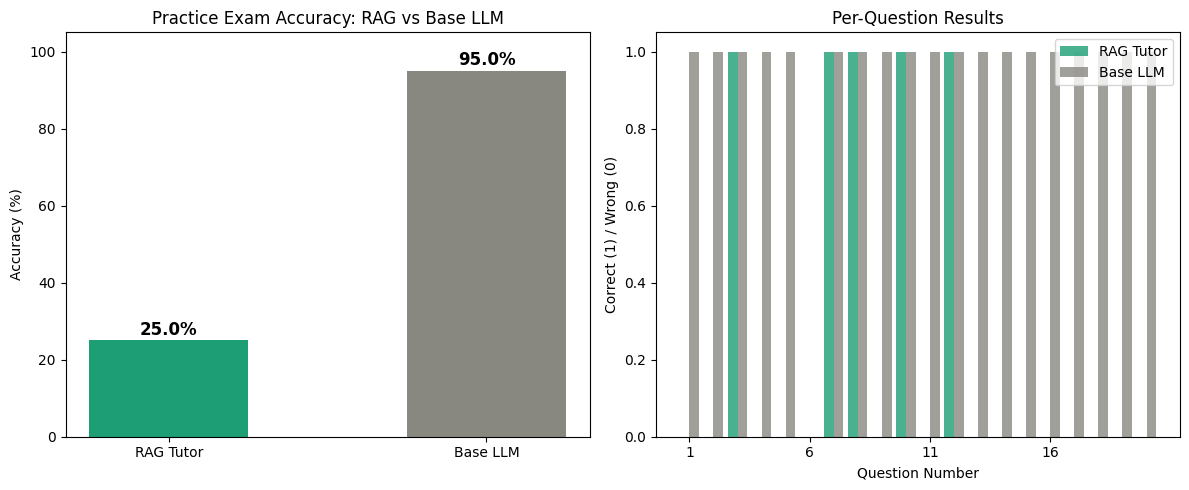

✓ Chart saved to results/evaluation_chart.png


In [22]:
import matplotlib.pyplot as plt
import numpy as np

# --- Bar chart: RAG vs Base accuracy ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Overall accuracy comparison
ax = axes[0]
labels = ["RAG Tutor", "Base LLM"]
accuracies = [100 * rag_correct / total, 100 * base_correct / total]
colors = ["#1D9E75", "#888780"]

bars = ax.bar(labels, accuracies, color=colors, width=0.5)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Practice Exam Accuracy: RAG vs Base LLM")
ax.set_ylim(0, 105)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{acc:.1f}%", ha="center", fontsize=12, fontweight="bold")

# Plot 2: Per-question comparison
ax = axes[1]
q_nums = [r["question_num"] for r in results]
rag_scores = [1 if r["rag_correct"] else 0 for r in results]
base_scores = [1 if r["base_correct"] else 0 for r in results]

x = np.arange(len(q_nums))
ax.bar(x - 0.2, rag_scores, 0.4, label="RAG Tutor", color="#1D9E75", alpha=0.8)
ax.bar(x + 0.2, base_scores, 0.4, label="Base LLM", color="#888780", alpha=0.8)
ax.set_xlabel("Question Number")
ax.set_ylabel("Correct (1) / Wrong (0)")
ax.set_title("Per-Question Results")
ax.legend()
ax.set_xticks(x[::5])
ax.set_xticklabels([q_nums[i] for i in range(0, len(q_nums), 5)])

plt.tight_layout()
plt.savefig("results/evaluation_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved to results/evaluation_chart.png")

## Section 6: Error Analysis

Which questions did the RAG tutor get wrong? Are there patterns?

In [23]:
# Questions the RAG tutor missed
rag_misses = [r for r in results if not r["rag_correct"]]

if rag_misses:
    print(f"RAG Tutor missed {len(rag_misses)} questions:\n")
    for r in rag_misses:
        q = exam_lookup.get(r["question_num"], {})
        print(f"Q{r['question_num']}: answered {r['rag_answer']}, correct was {r['correct_answer']}")
        print(f"  Topic: {q.get('objective', 'N/A')[:80]}")
        print()
else:
    print("RAG Tutor got all questions correct!")

# Questions ONLY the RAG tutor got right (base missed)
rag_advantage = [
    r for r in results
    if r["rag_correct"] and not r["base_correct"]
]
print(f"\nQuestions where RAG succeeded but Base failed: {len(rag_advantage)}")
for r in rag_advantage[:10]:
    print(f"  Q{r['question_num']}: RAG={r['rag_answer']}✓  Base={r['base_answer']}✗")

RAG Tutor missed 15 questions:

Q1: answered ?, correct was d
  Topic: Identify prokaryotic structures that promote interactions with a host and descri

Q2: answered ?, correct was d
  Topic: Compare and contrast the cell wall structure of Gram (+), Gram (-), and acid fas

Q4: answered ?, correct was c
  Topic: Describe 3 mechanisms that lead to horizontal transfer of DNA between bacterial 

Q5: answered ?, correct was b
  Topic: Describe the different classes of receptors and their roles in transmitting info

Q6: answered ?, correct was a
  Topic: In general terms, explain how the processes of heavy and light chain gene segmen

Q9: answered ?, correct was b
  Topic: Describe the process of detecting, transporting, and presenting to T cells, wher

Q11: answered ?, correct was c
  Topic: Describe how CD40L is important for T cell responses - refer to the consequences

Q13: answered ?, correct was a
  Topic: Compare and contrast the structures, mechanism of action, and roles in virulence

## Summary

This evaluation demonstrates whether retrieval-augmented generation improves
exam performance compared to a base LLM. The results, example outputs, and
visualizations above form the core evidence for the final project presentation.